In [1]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration

DEVICE = None

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

In [3]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration

model = LlavaForConditionalGeneration.from_pretrained("llava-hf/llava-1.5-7b-hf", dtype=torch.bfloat16, device_map=DEVICE, attn_implementation="eager")
processor = AutoProcessor.from_pretrained("llava-hf/llava-1.5-7b-hf")

conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": "https://www.ilankelman.org/stopsigns/australia.jpg"},
            {"type": "text", "text": "What is shown in this image?"},
        ],
    },
]

inputs = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt"
).to(DEVICE, torch.bfloat16)

generate_ids = model.generate(**inputs, max_new_tokens=30, output_attentions=True)
processor.batch_decode(generate_ids, skip_special_tokens=True)

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.18G [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


['USER:  \nWhat is shown in this image? ASSISTANT: The image shows a street scene with a stop sign, a lion statue, and a red building. There is also a car driving down the street']

In [25]:
print("Chat template result:")
print(f"Input IDs shape: {inputs['input_ids'].shape}")
if 'pixel_values' in inputs:
    print(f"Pixel values shape: {inputs['pixel_values'].shape}")

decoded_text = processor.tokenizer.decode(inputs['input_ids'][0], skip_special_tokens=False)
print(f"Decoded input text: {decoded_text}")
print(f"Count <image> tokens: {decoded_text.count('<image>')}")

Chat template result:
Input IDs shape: torch.Size([1, 595])
Pixel values shape: torch.Size([1, 3, 336, 336])
Decoded input text: <s> USER: <image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image>

In [ ]:
import math
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from typing import List, Union, Optional

def generate_response(model, processor, image_path, question, final_answer_tokens=1024):
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": question},
            ],
        },
    ]

    inputs = processor.apply_chat_template(
        conversation,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt"
    ).to(DEVICE, torch.bfloat16)

    with torch.no_grad():
        gen_output = model.generate(
            **inputs,
            max_new_tokens=final_answer_tokens,
            do_sample=False,
            output_attentions=True,
            return_dict_in_generate=True
        )

    # Extract output text
    input_ids = inputs['input_ids'][0].tolist()
    gen_ids = gen_output.sequences
    trimmed_ids = [out[len(inp):] for inp, out in zip(inputs.input_ids, gen_ids)]
    output_text = processor.batch_decode(trimmed_ids, skip_special_tokens=True)[0].strip()

    # Return both generated text and attentions
    return output_text, gen_output.attentions, input_ids, inputs['pixel_values']

def calculate_plt_size(attention_layer_num):
    cols = math.ceil(math.sqrt(attention_layer_num))
    rows = math.ceil(attention_layer_num / cols)
    return rows, cols

def calculate_accuracy(predicted, expected):
    predicted = str(predicted).lower().strip()
    expected = str(expected).lower().strip()
    return predicted in expected or expected in predicted

def plot_attention_map(
    attentions, 
    input_ids, 
    pixel_values, 
    processor, 
    image_path,
    output_dir=None, 
    token_pos=None,
    alpha=0.7
):
    # Find image token positions in LLaVA
    image_token_id = processor.tokenizer.convert_tokens_to_ids('<image>')
    image_positions = [i for i, token_id in enumerate(input_ids) if token_id == image_token_id]
    
    if not image_positions:
        print("No image tokens found in input_ids")
        return
    
    # For LLaVA, image tokens are typically 576 tokens (24x24 patches)
    pos = image_positions[0]
    pos_end = pos + 576  # Standard LLaVA image token count

    # Resize image to 336x336 (no need to preserve ratio)
    orig_img = Image.open(image_path).convert("RGB")
    resized_img = orig_img.resize((336, 336), Image.LANCZOS)
    resized_img_np = np.array(resized_img)

    # Calculate output shape for attention visualization
    # 576 tokens arranged as 24x24 patches
    output_shape = (24, 24)

    num_layers = len(attentions[0])
    num_generated_tokens = len(attentions)
    rows, cols = calculate_plt_size(num_layers)

    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.8, rows*2.8))

    # Determine which token positions to attend to
    if token_pos is None:
        att_token_idxs = [-1]
    elif isinstance(token_pos, (list, tuple, np.ndarray)):
        att_token_idxs = list(token_pos)
    else:
        att_token_idxs = [token_pos]

    # Prepare title for the plot
    if len(att_token_idxs) > 5:
        token_pos_str = ', '.join(str(x) for x in att_token_idxs[:5]) + ', ...'
    else:
        token_pos_str = ', '.join(str(x) for x in att_token_idxs)
    fig.suptitle(
        f"Attn Heatmap to Token Pos [{token_pos_str}]",
        fontsize=16, fontweight='bold', y=0.99, color="#222"
    )

    for i, ax in enumerate(np.array(axes).flatten()):
        if i < num_layers:
            layer_att = []
            for t in range(num_generated_tokens):
                # For each token position, get the attention, then average over token positions
                att_per_token = [
                    attentions[t][i][0, :, att_token_idx, pos:pos_end].mean(dim=0)
                    for att_token_idx in att_token_idxs
                ]
                att_per_token = torch.stack(att_per_token).mean(dim=0)  # average over token_pos
                layer_att.append(att_per_token)
            att = torch.stack(layer_att).mean(dim=0)  # average over generated tokens
            att = att.to(torch.float32).detach().cpu().numpy()
            
            # Reshape to 24x24 patches and resize to 336x336
            att_reshaped = att.reshape(output_shape)
            att_img = Image.fromarray((att_reshaped / att_reshaped.max() * 255).astype(np.uint8))
            att_resized = np.array(att_img.resize((336, 336), Image.NEAREST))

            ax.imshow(resized_img_np)
            ax.imshow(att_resized, cmap="viridis", interpolation="nearest", alpha=alpha)
            ax.set_title(f"Layer {i+1}", fontsize=10, pad=5)
            ax.axis("off")
        else:
            ax.axis("off")

    plt.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.04,
                        hspace=0.10, wspace=0.10)

    # If output_dir is not None or empty, save the plot, else just show
    if output_dir is not None and str(output_dir).strip() != "":
        heatmap_path = os.path.join(output_dir, f'attn_heatmap.png')
        os.makedirs(os.path.dirname(heatmap_path), exist_ok=True)
        plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

In [30]:
def process_single_sample(model, processor, image_path, question, output_dir=None, token_pos=None, alpha=0.7):
    output_text, attentions, input_ids, image_inputs = generate_response(model, processor, image_path, question, output_dir)
    plot_attention_map(attentions, input_ids, image_inputs, processor, image_path, output_dir, token_pos, alpha)
    return output_text, attentions

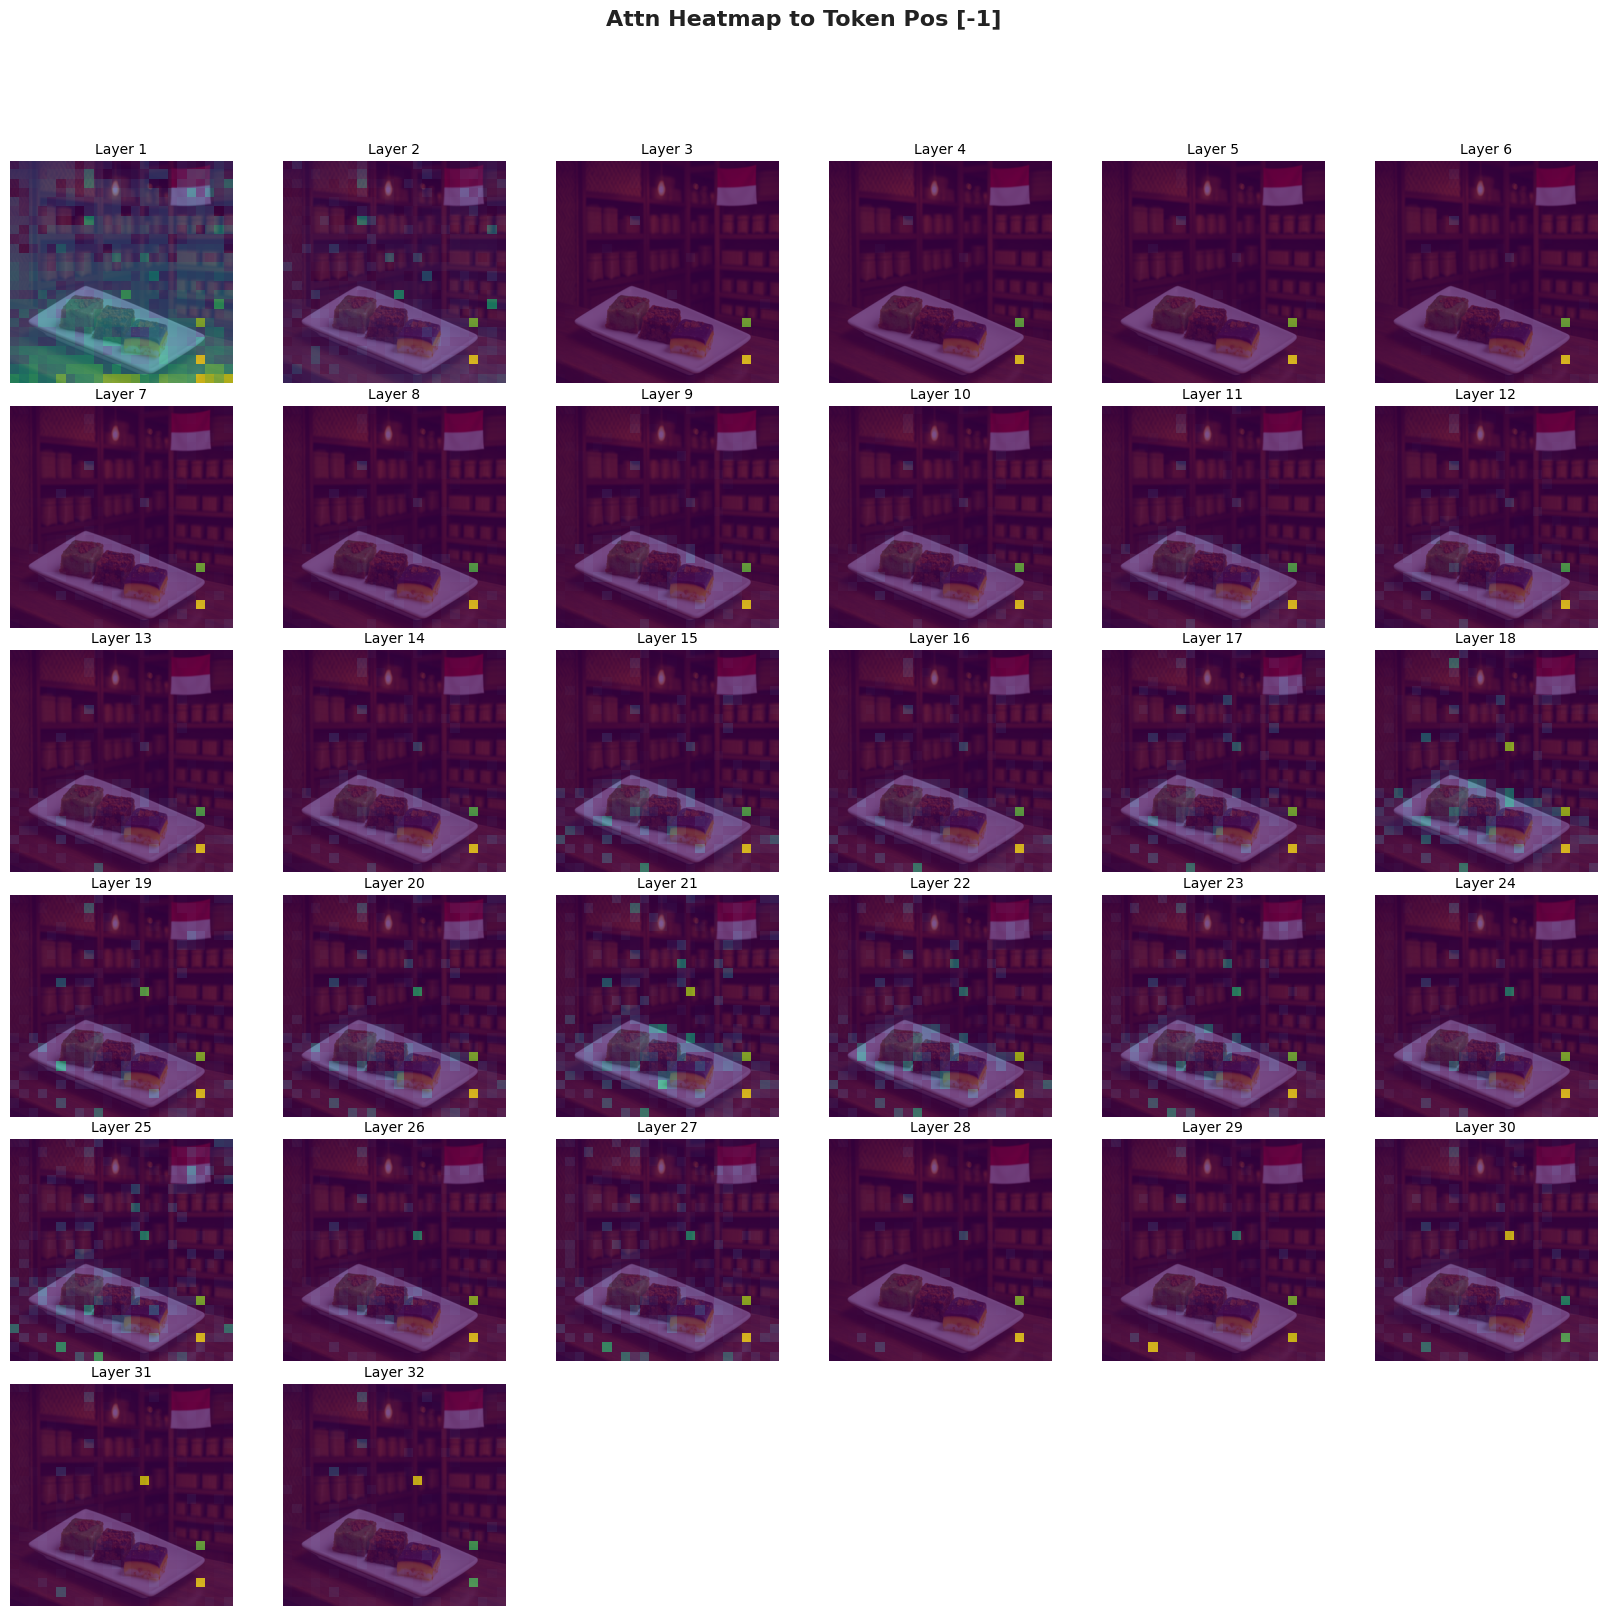

The image shows a plate with three different desserts on it, placed on a table.


In [31]:
PROMPT = "What is shown in this image?"
IMG_PATH = "../files/sapin.png"

response, attns = process_single_sample(model, processor, IMG_PATH, PROMPT)
print(response)

In [46]:
print("Generated Sequences:", len(attns))

Generated Sequences: 20


In [48]:
print("# Layers:", len(attns[0]))

# Layers: 32


In [ ]:
model.config

```
LlavaConfig {
  "architectures": [
    "LlavaForConditionalGeneration"
  ],
  "dtype": "bfloat16",
  "ignore_index": -100,
  "image_seq_length": 576,
  "image_token_index": 32000,
  "model_type": "llava",
  "multimodal_projector_bias": true,
  "pad_token_id": 32001,
  "projector_hidden_act": "gelu",
  "text_config": {
    "_name_or_path": "lmsys/vicuna-7b-v1.5",
    "architectures": [
      "LlamaForCausalLM"
    ],
    "attention_bias": false,
    "attention_dropout": 0.0,
    "dtype": "bfloat16",
    "head_dim": 128,
    "hidden_act": "silu",
    "hidden_size": 4096,
    "initializer_range": 0.02,
    "intermediate_size": 11008,
    "max_position_embeddings": 4096,
    "mlp_bias": false,
    "model_type": "llama",
    "num_attention_heads": 32,
    "num_hidden_layers": 32,
    "num_key_value_heads": 32,
    "pretraining_tp": 1,
    "rms_norm_eps": 1e-05,
    "rope_scaling": null,
    "rope_theta": 10000.0,
    "use_cache": true,
    "vocab_size": 32064
  },
  "tie_word_embeddings": false,
  "transformers_version": "4.56.1",
  "vision_config": {
    "attention_dropout": 0.0,
    "dtype": "bfloat16",
    "hidden_act": "quick_gelu",
    "hidden_size": 1024,
    "image_size": 336,
    "initializer_factor": 1.0,
    "initializer_range": 0.02,
    "intermediate_size": 4096,
    "layer_norm_eps": 1e-05,
    "model_type": "clip_vision_model",
    "num_attention_heads": 16,
    "num_channels": 3,
    "num_hidden_layers": 24,
    "patch_size": 14,
    "projection_dim": 768,
    "vocab_size": 32000
  },
  "vision_feature_layer": -2,
  "vision_feature_select_strategy": "default",
  "vocab_size": 32064
}
```

In [ ]:
image_token_id = model.config.image_token_index
input_ids = inputs['input_ids'][0]  # Get the first (and only) sequence
image_token_positions = (input_ids == image_token_id).nonzero(as_tuple=True)[0]

print(f"Image token ID: {image_token_id}")
print(f"Found {len(image_token_positions)} image token positions")

# Extract visual tokens based on image token positions
# Each image token corresponds to multiple visual feature tokens
if len(image_token_positions) > 0:
    # Get the start position of visual tokens
    visual_start = image_token_positions[0].item()
    # The number of visual tokens should be image_seq_length from config
    visual_seq_length = model.config.image_seq_length
    visual_end = visual_start + visual_seq_length
    
    print(f"Visual tokens span from position {visual_start} to {visual_end-1}")
    print(f"Expected visual sequence length: {visual_seq_length}")
    
    # Extract visual attention map
    visual_attn = attns[0][0][0][0][visual_start:visual_end, visual_start:visual_end]
    print(f"Visual attention shape: {visual_attn.shape}")
    
    # Verify the dimensions match expected patch grid
    patch_grid_size = int(visual_seq_length ** 0.5)
    expected_patch_grid = model.config.vision_config.image_size // model.config.vision_config.patch_size
    
    print(f"Patch grid size from visual tokens: {patch_grid_size}")
    print(f"Expected patch grid size: {expected_patch_grid}")
    
    assert visual_attn.shape == (visual_seq_length, visual_seq_length), \
        f"Visual attention dimensions {visual_attn.shape} don't match expected ({visual_seq_length}, {visual_seq_length})"
    
    assert patch_grid_size == expected_patch_grid, \
        f"Patch grid size {patch_grid_size} doesn't match expected {expected_patch_grid}"
    
    print("✓ Visual attention map dimensions are correct")
    print(f"✓ Patch grid is {patch_grid_size}x{patch_grid_size} as expected")
else:
    print("No image tokens found in input!")

Image token ID: 32000
Found 576 image token positions
Visual tokens span from position 5 to 580
Expected visual sequence length: 576
Visual attention shape: torch.Size([576, 576])
Patch grid size from visual tokens: 24
Expected patch grid size: 24
✓ Visual attention map dimensions are correct
✓ Patch grid is 24x24 as expected
